Using device: cpu

Dataset shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Class Distribution:
sentiment
1    25000
0    25000
Name: count, dtype: int64

Example cleaned review:
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that

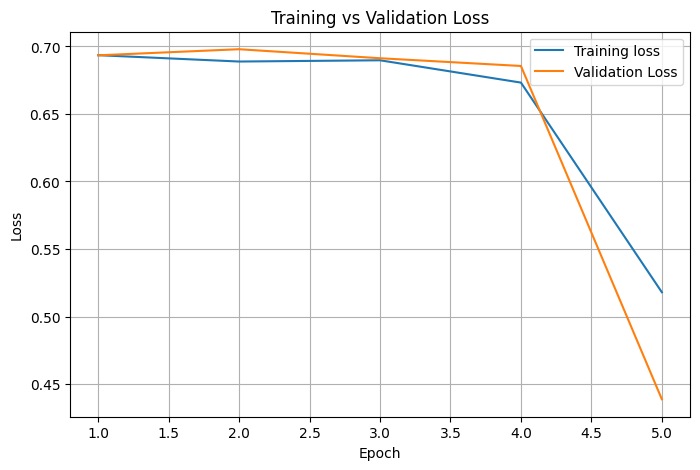

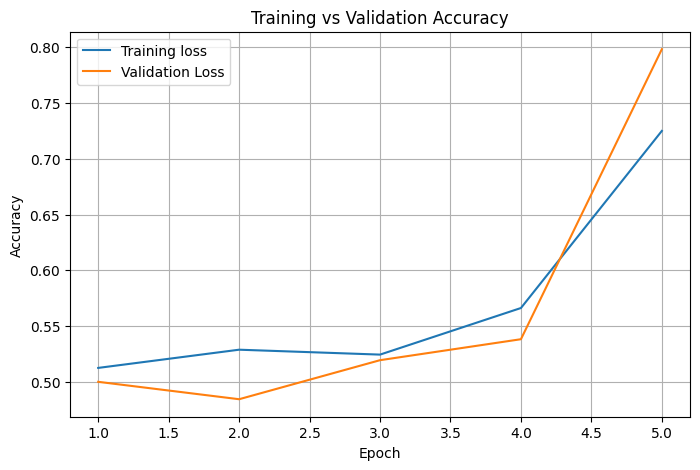


NEW REVIEW PREDICTIONS

Review: The movie was excellent and very enjoyable.
Predicted Sentiment: Positive
Confidence: 92.84%

Review: This was one of the worst movies I have ever watched.
Predicted Sentiment: Negative
Confidence: 89.00%

Review: Amazing acting and a fantastic story.
Predicted Sentiment: Negative
Confidence: 59.02%

Review: The movie was boring and completely disappointing.
Predicted Sentiment: Negative
Confidence: 94.03%



Enter a movie review (type 'exit' to quit):  The movie was excellent



Predicted Sentiment: Positive
Confidence: 79.90%



Enter a movie review (type 'exit' to quit):  The movie was nice



Predicted Sentiment: Positive
Confidence: 50.18%


...


Predicted Sentiment: Negative
Confidence: 60.56%



Enter a movie review (type 'exit' to quit):  The movie was not nice



Predicted Sentiment: Negative
Confidence: 69.06%



Enter a movie review (type 'exit' to quit):  The movie was amazing



Predicted Sentiment: Positive
Confidence: 73.29%


In [ ]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",DEVICE)
MAX_VOCAB_SIZE=10000
MAX_LENGTH=250
EMBEDDING_DIM=128
HIDDEN_DIM=128
NUM_LAYERS=1
DROPOUT=0.3
BATCH_SIZE=64
EPOCHS=5
LEARNING_RATE=0.001
PAD_TOKEN="<PAD>"
UNK_TOKEN="<UNK>"
DATA_PATH="IMDB Dataset.csv"
df=pd.read_csv(DATA_PATH)
print("\nDataset shape:",df.shape)
print(df.head())
df["sentiment"]=df["sentiment"].map({"positive":1,"negative":0})
print("\nClass Distribution:")
print(df["sentiment"].value_counts())
def clean_text(text):
    text=str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
df["clean_review"]=df["review"].apply(clean_text)
print("\nExample cleaned review:")
print(df["clean_review"].iloc[0])
train_df, temp_df = train_test_split(df,test_size=0.20,random_state=SEED,stratify=df["sentiment"])

val_df, test_df = train_test_split(temp_df,test_size=0.50,random_state=SEED,stratify=temp_df["sentiment"])
print("\nTrain size:",len(train_df))
print("Validation size:",len(val_df))
print("Test size:",len(test_df))
def tokenize(text):
    return text.split()
word_frequency={}
for review in train_df["clean_review"]:
    tokens=tokenize(review)
    for token in tokens:
        word_frequency[token]=word_frequency.get(token,0)+1
sorted_words=sorted(word_frequency.items(),key=lambda x:x[1],reverse=True)
vocab_words=sorted_words[:MAX_VOCAB_SIZE-2]
word_to_index={PAD_TOKEN:0,UNK_TOKEN:1}
for index,(word,frequency) in enumerate(vocab_words,start=2):
    word_to_index[word]=index
index_to_word={index:word for word,index in word_to_index.items()}
print("\nVocabulary size:",len(word_to_index))
def encode_review(text):
    tokens=tokenize(text)
    sequence=[word_to_index.get(token,word_to_index[UNK_TOKEN])
    for token in tokens]
    sequence=sequence[:MAX_LENGTH]
    if len(sequence)<MAX_LENGTH:
        sequence+=[word_to_index[PAD_TOKEN]]*(MAX_LENGTH-len(sequence))
    return sequence
class IMDBDataset(Dataset):
    def __init__(self,dataframe):
        self.reviews=dataframe["clean_review"].values
        self.labels=dataframe["sentiment"].values
    def __len__(self):
        return len(self.reviews)
    def __getitem__(self,index):
        review=self.reviews[index]
        label=self.labels[index]
        sequence=encode_review(review)
        return (torch.tensor(sequence,dtype=torch.long),torch.tensor(label,dtype=torch.float))
train_dataset=IMDBDataset(train_df)
val_dataset=IMDBDataset(val_df)
test_dataset=IMDBDataset(test_df)
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)
print("\nDataLoaders created")
class SentimentLSTM(nn.Module):
    def __init__(self,vocab_size,embedding_dim,hidden_dim,num_layers,dropout):
        super(SentimentLSTM,self).__init__()
        self.embedding=nn.Embedding(num_embeddings=vocab_size,embedding_dim=embedding_dim,padding_idx=word_to_index[PAD_TOKEN])
        self.lstm=nn.LSTM(input_size=embedding_dim,hidden_size=hidden_dim,num_layers=num_layers,batch_first=True,dropout=dropout if num_layers>1 else 0)
        self.dropout=nn.Dropout(dropout)
        self.fc=nn.Linear(hidden_dim,1)
    def forward(self,x):
        embedded=self.embedding(x)
        output,(hidden,cell)=self.lstm(embedded)
        hidden=hidden[-1]
        hidden=self.dropout(hidden)
        output=self.fc(hidden)
        return output.squeeze(1)
model=SentimentLSTM(vocab_size=len(word_to_index),embedding_dim=EMBEDDING_DIM,hidden_dim=HIDDEN_DIM,num_layers=NUM_LAYERS,dropout=DROPOUT)
model=model.to(DEVICE)
print("\nModel:")
print(model)
criterion=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)
def train_model(model,loader):
    model.train()
    total_loss=0
    all_predictions=[]
    all_labels=[]
    for reviews,labels in loader:
        reviews=reviews.to(DEVICE)
        labels=labels.to(DEVICE)
        optimizer.zero_grad()
        outputs=model(reviews)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
        probabilites=torch.sigmoid(outputs)
        predictions=(probabilites>=0.5).long()
        all_predictions.extend(predictions.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    average_loss=total_loss/len(loader)
    accuracy=accuracy_score(all_labels,all_predictions)
    precision=precision_score(all_labels,all_predictions,zero_division=0)
    recall=recall_score(all_labels,all_predictions,zero_division=0)
    f1=f1_score(all_labels,all_predictions,zero_division=0)
    return (average_loss,accuracy,precision,recall,f1)
def evaluate_model(model,loader):
    model.eval()
    total_loss=0
    all_predictions=[]
    all_labels=[]
    with torch.no_grad():
        for reviews,labels in loader:
            reviews=reviews.to(DEVICE)
            labels=labels.to(DEVICE)
            outputs=model(reviews)
            loss=criterion(outputs,labels)
            total_loss+=loss.item()
            probabilities=torch.sigmoid(outputs)
            predictions=(probabilities>=0.5).long()
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    average_loss=total_loss/len(loader)
    accuracy=accuracy_score(all_labels,all_predictions)
    precision=precision_score(all_labels,all_predictions,zero_division=0)
    recall=recall_score(all_labels,all_predictions,zero_division=0)
    f1=f1_score(all_labels,all_predictions,zero_division=0)
    return (average_loss,accuracy,precision,recall,f1)
train_losses=[]
val_losses=[]
train_accuracies=[]
val_accuracies=[]
train_precisions=[]
val_precisions=[]
train_recalls=[]
val_recalls=[]
train_fls=[]
val_fls=[]
best_val_loss=float("inf")
print("\nStarting training..\n")
for epoch in range(EPOCHS):
    train_results=train_model(model,train_loader)
    val_results=evaluate_model(model,val_loader)
    (train_loss,train_accuracy,train_precision,train_recall,train_f1)=train_results
    (val_loss,val_accuracy,val_precision,val_recall,val_f1)=val_results
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    train_precisions.append(train_precision)
    val_precisions.append(val_precision)
    train_recalls.append(train_recall)
    val_recalls.append(val_recall)
    train_fls.append(train_f1)
    val_fls.append(val_f1)
    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: {train_accuracy * 100:.2f}%"
    )

    print(
        f"Train Precision: {train_precision * 100:.2f}%"
    )

    print(
        f"Train Recall: {train_recall * 100:.2f}%"
    )

    print(
        f"Train F1: {train_f1 * 100:.2f}%"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: {val_accuracy * 100:.2f}%"
    )

    print(
        f"Validation Precision: {val_precision * 100:.2f}%"
    )

    print(
        f"Validation Recall: {val_recall * 100:.2f}%"
    )

    print(
        f"Validation F1: {val_f1 * 100:.2f}%"
    )
    print("-"*60)
    if val_loss<best_val_loss:
        best_val_loss=val_loss
        torch.save(model.state_dict(),"best_lstm_sentiment_model.pth")
print("\nTraining completed")
model.load_state_dict(torch.load("best_lstm_sentiment_model.pth",map_location=DEVICE))
test_results=evaluate_model(model,test_loader)
(test_loss,test_accuracy,test_precision,test_recall,test_f1)=test_results
print("\n"+"="*60)
print("FINAL TEST RESULTS")
print("="*60)
print(
    f"Test Loss      : {test_loss:.4f}"
)

print(
    f"Accuracy       : {test_accuracy * 100:.2f}%"
)

print(
    f"Precision      : {test_precision * 100:.2f}%"
)

print(
    f"Recall         : {test_recall * 100:.2f}%"
)

print(
    f"F1-Score       : {test_f1 * 100:.2f}%"
)

print("=" * 60)
plt.figure(figsize=(8,5))
plt.plot(range(1,EPOCHS+1),train_losses,label="Training loss")
plt.plot(range(1,EPOCHS+1),val_losses,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()
plt.figure(figsize=(8,5))
plt.plot(range(1,EPOCHS+1),train_accuracies,label="Training loss")
plt.plot(range(1,EPOCHS+1),val_accuracies,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()
def predict_sentiment(review):
    model.eval()
    cleaned_review = clean_text(review)
    sequence = encode_review(cleaned_review)
    tensor = torch.tensor([sequence],dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        output = model(tensor)
        probability = torch.sigmoid(output).item()

    if probability >= 0.5:
        sentiment = "Positive"
        confidence = probability * 100
    else:
        sentiment = "Negative"
        confidence = (1 - probability) * 100
    return sentiment, confidence
reviews = [
    "The movie was excellent and very enjoyable.",
    "This was one of the worst movies I have ever watched.",
    "Amazing acting and a fantastic story.",
    "The movie was boring and completely disappointing."]

print("\nNEW REVIEW PREDICTIONS")
print("=" * 60)
for review in reviews:
    sentiment, confidence = predict_sentiment(review)
    print("\nReview:", review)
    print(
        "Predicted Sentiment:",
        sentiment
    )

    print(
        f"Confidence: {confidence:.2f}%"
    )

while True:

    review = input("\nEnter a movie review ""(type 'exit' to quit): ")
    if review.lower() == "exit":
        break
    sentiment, confidence = predict_sentiment(review)

    print("\nPredicted Sentiment:",sentiment)

    print( f"Confidence: {confidence:.2f}%")